In [2]:
import pandas as pd
import numpy as np
import joblib
import os

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
np.random.seed(42)

ARTIFACT_DIR = "ml_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

In [5]:
def generate_training_data(n=6000):

    weak = pd.DataFrame({
        "overall_score": np.random.uniform(0,45,n//3),
        "quiz_average": np.random.uniform(0,40,n//3),
        "assignment_average": np.random.uniform(0,40,n//3),
        "completion_rate": np.random.uniform(0,30,n//3),
        "avg_watch_time": np.random.uniform(0,100,n//3),
        "quiz_attempt_rate": np.random.uniform(0,30,n//3),
        "assignment_submission_rate": np.random.uniform(0,30,n//3),
        "videos_completed": np.random.randint(0,5,n//3),
        "quizzes_attempted": np.random.randint(0,3,n//3),
        "assignments_submitted": np.random.randint(0,2,n//3),
        "total_course_items": np.random.randint(10,40,n//3)
    })

    weak["level"] = "Weak"

    avg = pd.DataFrame({
        "overall_score": np.random.uniform(46,79,n//3),
        "quiz_average": np.random.uniform(40,75,n//3),
        "assignment_average": np.random.uniform(40,75,n//3),
        "completion_rate": np.random.uniform(30,70,n//3),
        "avg_watch_time": np.random.uniform(100,300,n//3),
        "quiz_attempt_rate": np.random.uniform(30,70,n//3),
        "assignment_submission_rate": np.random.uniform(30,70,n//3),
        "videos_completed": np.random.randint(5,12,n//3),
        "quizzes_attempted": np.random.randint(3,8,n//3),
        "assignments_submitted": np.random.randint(2,6,n//3),
        "total_course_items": np.random.randint(10,40,n//3)
    })

    avg["level"] = "Average"

    strong = pd.DataFrame({
        "overall_score": np.random.uniform(80,100,n//3),
        "quiz_average": np.random.uniform(76,100,n//3),
        "assignment_average": np.random.uniform(76,100,n//3),
        "completion_rate": np.random.uniform(70,100,n//3),
        "avg_watch_time": np.random.uniform(300,600,n//3),
        "quiz_attempt_rate": np.random.uniform(70,100,n//3),
        "assignment_submission_rate": np.random.uniform(70,100,n//3),
        "videos_completed": np.random.randint(12,25,n//3),
        "quizzes_attempted": np.random.randint(8,15,n//3),
        "assignments_submitted": np.random.randint(6,12,n//3),
        "total_course_items": np.random.randint(10,40,n//3)
    })

    strong["level"] = "Strong"

    df = pd.concat([weak,avg,strong]).sample(frac=1).reset_index(drop=True)

    return df



In [6]:
def engineer_features(df):

    df["engagement_score"] = (
        0.4 * df["completion_rate"] +
        0.3 * df["quiz_attempt_rate"] +
        0.3 * df["assignment_submission_rate"]
    )

    df["performance_score"] = (
        0.4 * df["quiz_average"] +
        0.6 * df["assignment_average"]
    )

    df["activity_score"] = (
        df["videos_completed"] +
        df["quizzes_attempted"] +
        df["assignments_submitted"]
    )

    return df

In [7]:
def create_risk_label(df):

    conditions = (
        (df["completion_rate"] < 40) |
        (df["quiz_attempt_rate"] < 40) |
        (df["assignment_submission_rate"] < 40) |
        (df["overall_score"] < 50)
    )

    df["dropout_risk"] = conditions.astype(int)

    return df


Generating dataset...
Dataset shape: (6000, 16)

Training model...

Best Parameters:
{'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}

Cross Validation Accuracy: 0.9985416666666665

Accuracy: 0.9975

ROC AUC: 0.9999832167832168

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       550
           1       1.00      1.00      1.00       650

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



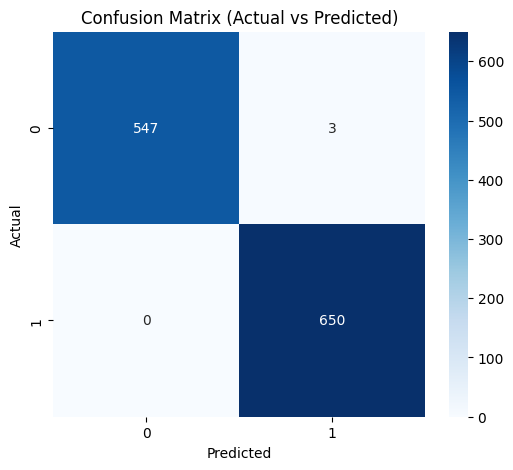


Top Important Features

                       feature  importance
11            engagement_score    0.227544
5            quiz_attempt_rate    0.181293
6   assignment_submission_rate    0.161708
3              completion_rate    0.118941
0                overall_score    0.059788
4               avg_watch_time    0.055618
13              activity_score    0.049309
2           assignment_average    0.039015
12           performance_score    0.025127
7             videos_completed    0.022700

Model saved successfully


In [13]:
def train_model():

    print("\nGenerating dataset...")

    df = generate_training_data()

    df = engineer_features(df)

    df = create_risk_label(df)

    X = df.drop(["level","dropout_risk"],axis=1)

    y = df["dropout_risk"]

    print("Dataset shape:",df.shape)

    X_train,X_test,y_train,y_test = train_test_split(
        X,y,test_size=0.2,random_state=42,stratify=y
    )

    # =================================================
    # HYPERPARAMETER TUNING
    # =================================================

    param_grid = {

        "n_estimators":[100,200,300],
        "max_depth":[10,15,20],
        "min_samples_split":[2,5],
        "min_samples_leaf":[1,2]

    }

    rf = RandomForestClassifier(random_state=42,class_weight="balanced")

    grid = GridSearchCV(
        rf,
        param_grid,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    )

    print("\nTraining model...")

    grid.fit(X_train,y_train)

    best_model = grid.best_estimator_

    print("\nBest Parameters:")
    print(grid.best_params_)

    # =================================================
    # CROSS VALIDATION
    # =================================================

    cv_scores = cross_val_score(best_model,X_train,y_train,cv=5)

    print("\nCross Validation Accuracy:",cv_scores.mean())

    # =================================================
    # MODEL EVALUATION
    # =================================================

    y_pred = best_model.predict(X_test)

    y_prob = best_model.predict_proba(X_test)[:,1]

    print("\nAccuracy:",accuracy_score(y_test,y_pred))

    print("\nROC AUC:",roc_auc_score(y_test,y_prob))

    print("\nClassification Report:\n")

    print(classification_report(y_test,y_pred))

    # =================================================
    # CONFUSION MATRIX
    # =================================================

    cm = confusion_matrix(y_test,y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

    plt.title("Confusion Matrix (Actual vs Predicted)")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

    # =================================================
    # FEATURE IMPORTANCE
    # =================================================

    importance = best_model.feature_importances_

    feature_names = X.columns

    imp_df = pd.DataFrame({
        "feature":feature_names,
        "importance":importance
    }).sort_values("importance",ascending=False)

    print("\nTop Important Features\n")

    print(imp_df.head(10))

    # =================================================
    # SAVE MODEL
    # =================================================

    joblib.dump(best_model,ARTIFACT_DIR+"/dropout_model.pkl")

    joblib.dump(feature_names.tolist(),ARTIFACT_DIR+"/model_features.pkl")

    print("\nModel saved successfully")


if __name__ == "__main__":

    train_model()

In [ ]:
# Prediction Audit Table

audit_df = X_test.copy()

audit_df["actual"] = y_test.values
audit_df["predicted"] = y_pred
audit_df["probability"] = y_prob

print("Sample Predictions:\n")

display(audit_df.head(20))


# Wrong predictions
wrong_predictions = audit_df[audit_df["actual"] != audit_df["predicted"]]

print("\nWrong predictions:", len(wrong_predictions))

display(wrong_predictions)


# Save for checking
audit_df.to_csv("prediction_audit.csv", index=False)

print("\nAudit file saved as prediction_audit.csv")